In [ ]:
import pandas as pd
import os
import glob
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

print("Please upload all 10 of your .csv files...")
uploaded = files.upload()

print(f"\nSuccessfully uploaded {len(uploaded)} files.")

Please upload all 10 of your .csv files...


Saving Dhan - Aditya Birla Sun Life Floating Rate Fund Direct - Growth NAV History - 5 Years.csv to Dhan - Aditya Birla Sun Life Floating Rate Fund Direct - Growth NAV History - 5 Years (1).csv
Saving Dhan - Franklin India Floating Rate Fund Direct - Growth NAV History - 5 Years.csv to Dhan - Franklin India Floating Rate Fund Direct - Growth NAV History - 5 Years (1).csv
Saving Dhan - HDFC Floating Rate Debt Fund Direct - Growth NAV History - 5 Years.csv to Dhan - HDFC Floating Rate Debt Fund Direct - Growth NAV History - 5 Years (1).csv
Saving Dhan - ICICI Prudential Floating Interest Fund Direct - Growth NAV History - 5 Years.csv to Dhan - ICICI Prudential Floating Interest Fund Direct - Growth NAV History - 5 Years (1).csv
Saving Dhan - Kotak Floating Rate Fund Direct - Growth NAV History - 5 Years.csv to Dhan - Kotak Floating Rate Fund Direct - Growth NAV History - 5 Years (1).csv
Saving Dhan - Nippon India Floater Fund Direct - Growth NAV History - 5 Years.csv to Dhan - Nippon Ind

In [ ]:
# Find all the NAV history files you uploaded
nav_history_files = glob.glob("Dhan - *.csv")
all_nav_data = []

print(f"Found {len(nav_history_files)} NAV history files to merge.")

for filename in nav_history_files:
    try:
        # Extract the fund name from the filename
        # Format: "Dhan - [Fund Name] NAV History - 5 Years.csv"
        fund_name = os.path.basename(filename).split(' NAV History')[0].split(' - ', 1)[1]

        # Read the individual CSV
        df = pd.read_csv(filename)

        # Add the new 'Fund Name' column
        df['Fund Name'] = fund_name

        # Add this dataframe to our list
        all_nav_data.append(df)
        print(f"Processed: {fund_name}")

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# Concatenate all dataframes in the list into one single dataframe
if all_nav_data:
    merged_nav_df = pd.concat(all_nav_data, ignore_index=True)
    print("\nSuccessfully merged all NAV history files.")
else:
    print("\nNo NAV files were processed. Please check file names.")

Found 16 NAV history files to merge.
Processed: SBI Floating Rate Debt Fund Direct - Growth
Processed: SBI Floating Rate Debt Fund Direct - Growth
Processed: Aditya Birla Sun Life Floating Rate Fund Direct - Growth
Processed: UTI Floater Fund Direct - Growth
Processed: Kotak Floating Rate Fund Direct - Growth
Processed: ICICI Prudential Floating Interest Fund Direct - Growth
Processed: Aditya Birla Sun Life Floating Rate Fund Direct - Growth
Processed: HDFC Floating Rate Debt Fund Direct - Growth
Processed: Nippon India Floater Fund Direct - Growth
Processed: Franklin India Floating Rate Fund Direct - Growth
Processed: Franklin India Floating Rate Fund Direct - Growth
Processed: UTI Floater Fund Direct - Growth
Processed: HDFC Floating Rate Debt Fund Direct - Growth
Processed: Nippon India Floater Fund Direct - Growth
Processed: Kotak Floating Rate Fund Direct - Growth
Processed: ICICI Prudential Floating Interest Fund Direct - Growth

Successfully merged all NAV history files.


In [ ]:
if 'merged_nav_df' in locals():
    print("--- Merged NAV Data Info ---")
    merged_nav_df.info()

    print("\n\n--- First 5 Rows ---")
    print(merged_nav_df.head())

    print("\n\n--- Last 5 Rows ---")
    print(merged_nav_df.tail())

    print("\n\n--- Funds Included ---")
    print(merged_nav_df['Fund Name'].value_counts())

--- Merged NAV Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19048 entries, 0 to 19047
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       19048 non-null  object
 1   NAV        19048 non-null  object
 2   Change     19048 non-null  object
 3   Change(%)  19048 non-null  object
 4   Fund Name  19048 non-null  object
dtypes: object(5)
memory usage: 744.2+ KB


--- First 5 Rows ---
         Date      NAV Change Change(%)  \
0  2025-11-11  13.7207  -0.01    -0.06%   
1  2025-11-10   13.729   0.01     0.07%   
2  2025-11-07  13.7198   0.00     0.00%   
3  2025-11-06  13.7193   0.01     0.11%   
4  2025-11-04  13.7047   0.02     0.12%   

                                     Fund Name  
0  SBI Floating Rate Debt Fund Direct - Growth  
1  SBI Floating Rate Debt Fund Direct - Growth  
2  SBI Floating Rate Debt Fund Direct - Growth  
3  SBI Floating Rate Debt Fund Direct - Growth  
4  SBI Floating Rate 

In [ ]:
# Note: These filenames must match what you uploaded EXACTLY.
# I am using the filenames from your prompt.

try:
    # This file has 1 junk row at the top
    historic_returns_df = pd.read_excel(
        "Historic Returns - floater fund,floater fund Performance Tracker Mutual funds with highest returns - Moneycontrol.com (1).xlsx",
        skiprows=1
    )
    print("--- Loaded Historic Returns File ---")
    print(historic_returns_df.head())

except FileNotFoundError:
    print("Could not find the 'Historic Returns' file. Please check the filename.")


try:
    # This file has 2 junk rows at the top
    sip_performance_df = pd.read_excel(
        "Top-Performing-Systematic-Investment-Plan.xlsx",
        skiprows=2
    )
    print("\n\n--- Loaded SIP Performance File ---")
    print(sip_performance_df.head())

except FileNotFoundError:
    print("Could not find the 'Top-Performing-Systematic-Investment-Plan' file. Please check the filename.")

--- Loaded Historic Returns File ---
                                         Scheme Name         Plan  \
0            DSP Floater Fund - Direct Plan - Growth  Direct Plan   
1  SBI Floating Rate Debt Fund - Direct Plan - Gr...  Direct Plan   
2        Bandhan Floater Fund - Direct Plan - Growth  Direct Plan   
3  ICICI Prudential Floating Interest Fund - Dire...  Direct Plan   
4  HDFC Floating Rate Debt Fund - Direct Plan - G...  Direct Plan   

  Category Name Crisil Rating  AuM (Cr)   YTM      1W      1M      3M      6M  \
0  Floater Fund             -    520.76  6.53  0.0035  0.0062  0.0156  0.0310   
1  Floater Fund             -    812.49  6.60  0.0034  0.0030  0.0121  0.0316   
2  Floater Fund             -    297.76  7.10  0.0026  0.0058  0.0167  0.0333   
3  Floater Fund             1   7132.62  7.12  0.0022  0.0070  0.0171  0.0387   
4  Floater Fund             3  15445.52  7.14  0.0021  0.0059  0.0162  0.0366   

      YTD      1Y      2Y      3Y      5Y     10Y  
0  0.0728

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [ ]:
if 'merged_nav_df' in locals():
    # --- Date Index Logic (Your code is correct) ---
    if 'Date' in merged_nav_df.columns:
        try:
            merged_nav_df['Date'] = pd.to_datetime(merged_nav_df['Date'])
        except Exception as e:
            print(f"Date parse error: {e}. Trying dayfirst=True...")
            try:
                merged_nav_df['Date'] = pd.to_datetime(merged_nav_df['Date'], dayfirst=True)
            except Exception as e2:
                print(f"Date conversion failed. Error: {e2}")

        merged_nav_df = merged_nav_df.set_index('Date')
    else:
        print("'Date' column not found, assuming it's already the index.")
        if not pd.api.types.is_datetime64_any_dtype(merged_nav_df.index):
            merged_nav_df.index = pd.to_datetime(merged_nav_df.index)

    # --- NAV Cleaning (Your code is correct) ---
    if 'NAV' in merged_nav_df.columns:
        merged_nav_df['NAV'] = merged_nav_df['NAV'].astype(str).str.replace(',', '', regex=False)
        merged_nav_df['NAV'] = pd.to_numeric(merged_nav_df['NAV'], errors='coerce')

    # --- NEW: Clean 'Change' and 'Change(%)' columns ---

    # Clean 'Change' column
    if 'Change' in merged_nav_df.columns:
        merged_nav_df['Change'] = pd.to_numeric(merged_nav_df['Change'], errors='coerce')

    # Clean 'Change(%)' column
    if 'Change(%)' in merged_nav_df.columns:
        # Remove '%' sign and convert to numeric
        merged_nav_df['Change(%)'] = merged_nav_df['Change(%)'].astype(str).str.replace('%', '', regex=False)
        merged_nav_df['Change(%)'] = pd.to_numeric(merged_nav_df['Change(%)'], errors='coerce')

    print("--- Cleaned NAV Data Info (with Change columns) ---")
    merged_nav_df.info()

    print("\n\n--- Data Head After Cleaning ---")
    print(merged_nav_df.head())

'Date' column not found, assuming it's already the index.
--- Cleaned NAV Data Info (with Change columns) ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 19048 entries, 2025-11-11 to 2020-12-08
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   NAV        19048 non-null  float64
 1   Change     19000 non-null  float64
 2   Change(%)  18888 non-null  float64
 3   Fund Name  19048 non-null  object 
dtypes: float64(3), object(1)
memory usage: 744.1+ KB


--- Data Head After Cleaning ---
                NAV  Change  Change(%)  \
Date                                     
2025-11-11  13.7207   -0.01      -0.06   
2025-11-10  13.7290    0.01       0.07   
2025-11-07  13.7198    0.00       0.00   
2025-11-06  13.7193    0.01       0.11   
2025-11-04  13.7047    0.02       0.12   

                                              Fund Name  
Date                                                     
2025-11-11  SBI Floating 

Pivoting data for plotting...
Generating plot...


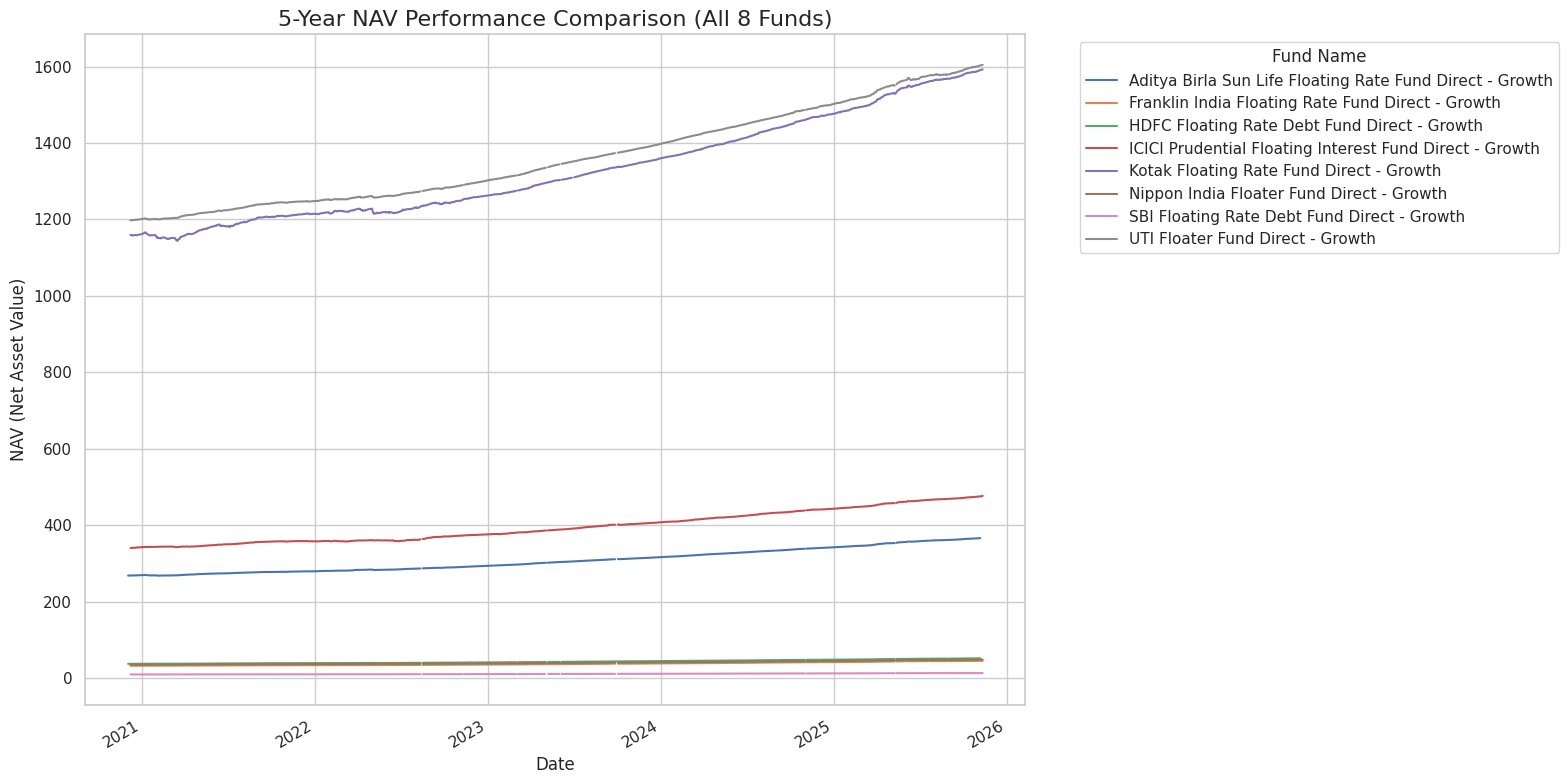

In [ ]:
# --- Corrected Cell 6 ---

if 'merged_nav_df' in locals():
    print("Pivoting data for plotting...")

    # Pivot the data to have Dates as rows and Fund Names as columns
    # **Use 'NAV' (uppercase) here**
    nav_pivot = merged_nav_df.pivot_table(
        index=merged_nav_df.index,
        columns='Fund Name',
        values='NAV'  # <-- This is the correction
    )

    print("Generating plot...")

    # Plot the pivoted data
    plt.figure(figsize=(16, 8))
    nav_pivot.plot(ax=plt.gca())

    plt.title('5-Year NAV Performance Comparison (All 8 Funds)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('NAV (Net Asset Value)', fontsize=12)

    # Move the legend outside the plot
    plt.legend(title='Fund Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

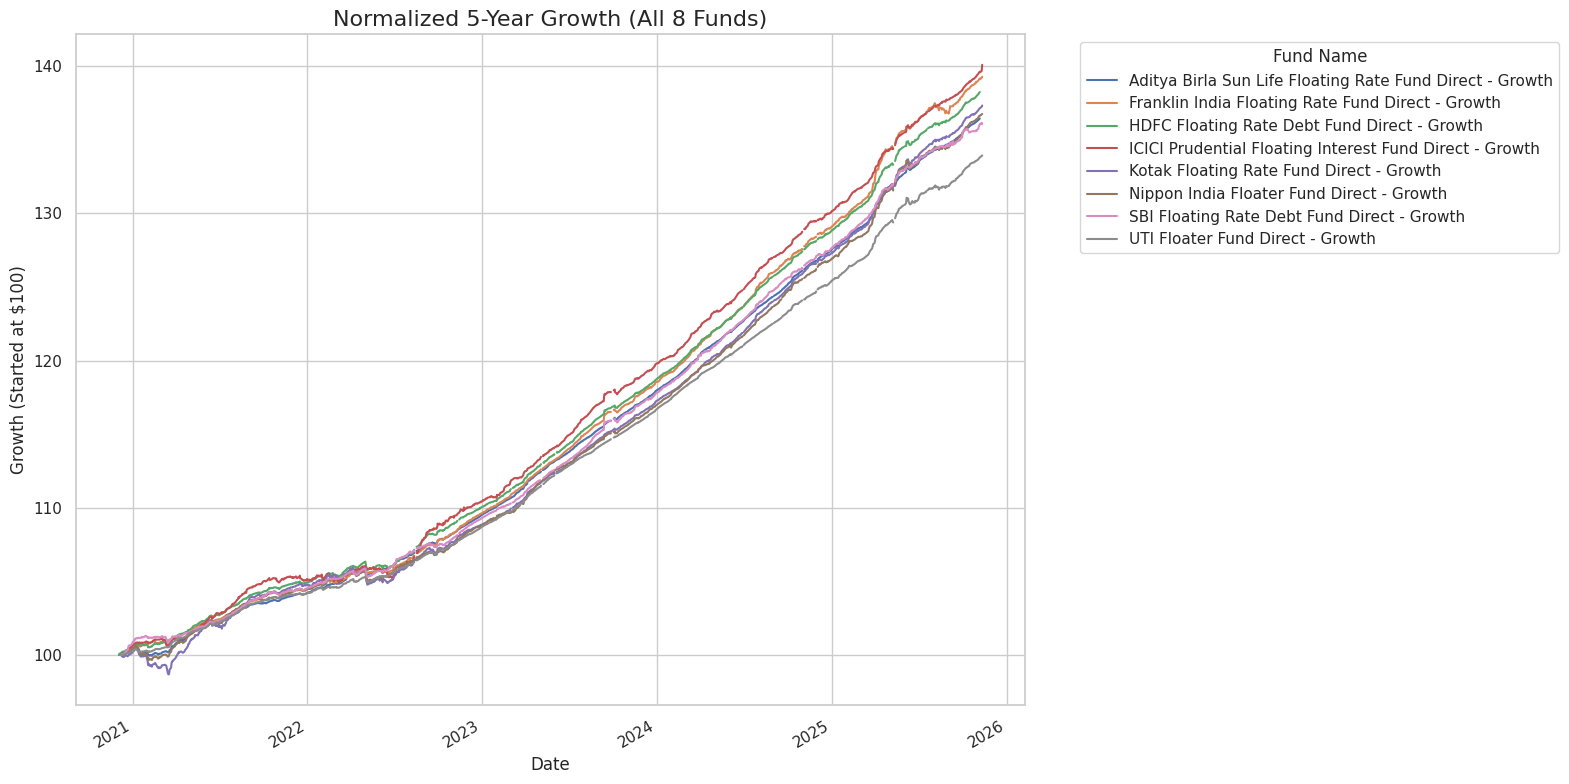

In [ ]:
if 'nav_pivot' in locals():
    # --- THIS IS THE CORRECTED LINE ---
    # Normalize each column by its *own* first valid value, not the DataFrame's first row.
    normalized_nav = nav_pivot.apply(lambda x: (x / x.dropna().iloc[0]) * 100)
    # --- END OF CORRECTION ---

    # Plot the normalized data
    plt.figure(figsize=(16, 8))
    normalized_nav.plot(ax=plt.gca())

    plt.title('Normalized 5-Year Growth (All 8 Funds)', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Growth (Started at $100)', fontsize=12)

    # Move the legend outside the plot
    plt.legend(title='Fund Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
# Check if the DataFrames exist before saving
try:
    if 'merged_nav_df' in locals():
        merged_nav_df.to_csv('Group#_Data_Merged_NAV_History.csv')
        print("Successfully saved: Group#_Data_Merged_NAV_History.csv")

    if 'historic_returns_df' in locals():
        historic_returns_df.to_csv('Group#_Data_Historic_Returns.csv', index=False)
        print("Successfully saved: Group#_Data_Historic_Returns.csv")

    if 'sip_performance_df' in locals():
        sip_performance_df.to_csv('Group#_Data_SIP_Performance.csv', index=False)
        print("Successfully saved: Group#_Data_SIP_Performance.csv")

except Exception as e:
    print(f"An error occurred while saving: {e}")

Successfully saved: Group#_Data_Merged_NAV_History.csv
Successfully saved: Group#_Data_Historic_Returns.csv
Successfully saved: Group#_Data_SIP_Performance.csv


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We assume all libraries from previous cells are loaded
print("Please upload your 3 new Excel files:")
print("1. Mutual-Fund-Annual-Returns.xlsx")
print("2. Top-Performing-Mutual-Funds-Trailing-returns.xlsx")
print("3. Top-Performing-Systematic-Investment-Plan.xlsx")
uploaded_summary = files.upload()

print(f"\nSuccessfully uploaded {len(uploaded_summary)} new files.")

Please upload your 3 new Excel files:
1. Mutual-Fund-Annual-Returns.xlsx
2. Top-Performing-Mutual-Funds-Trailing-returns.xlsx
3. Top-Performing-Systematic-Investment-Plan.xlsx


Saving Mutual-Fund-Annual-Returns.xlsx to Mutual-Fund-Annual-Returns.xlsx
Saving Top-Performing-Mutual-Funds-Trailing-returns.xlsx to Top-Performing-Mutual-Funds-Trailing-returns.xlsx
Saving Top-Performing-Systematic-Investment-Plan.xlsx to Top-Performing-Systematic-Investment-Plan (1).xlsx

Successfully uploaded 3 new files.


In [ ]:
# --- Corrected Cell 9 ---

try:
    # estimatedRowsAboveHeader: 2. Header is on row index 2.
    annual_ret_df = pd.read_excel(
        "Mutual-Fund-Annual-Returns.xlsx",
        skiprows=2,
        header=0
    )
    print("--- Loaded Mutual Fund Annual Returns ---")
    print(f"Columns: {list(annual_ret_df.columns)}")
    print(annual_ret_df.head())

except Exception as e:
    print(f"Error loading 'Mutual-Fund-Annual-Returns.xlsx': {e}")


try:
    # estimatedRowsAboveHeader: 3. Header starts on row index 3.
    # This file has a 2-level header (e.g., '1 Week' and 'Returns').
    trailing_ret_df = pd.read_excel(
        "Top-Performing-Mutual-Funds-Trailing-returns.xlsx",
        skiprows=3,
        header=[0, 1] # Read the first two rows as a MultiIndex
    )
    print("\n--- Loaded Top Performing Trailing Returns (MultiIndex) ---")
    print(f"Columns: {list(trailing_ret_df.columns)}")
    print(trailing_ret_df.head())

except Exception as e:
    print(f"Error loading 'Top-Performing-Mutual-Funds-Trailing-returns.xlsx': {e}")


try:
    # This file loaded correctly before.
    sip_ret_df = pd.read_excel(
        "Top-Performing-Systematic-Investment-Plan.xlsx",
        skiprows=2,
        header=0
    )
    print("\n--- Loaded Top Performing SIP ---")
    print(f"Columns: {list(sip_ret_df.columns)}")
    print(sip_ret_df.head())

except Exception as e:
    print(f"Error loading 'Top-Performing-Systematic-Investment-Plan.xlsx': {e}")

--- Loaded Mutual Fund Annual Returns ---
Columns: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 2025, 2024, 2023, 2022, 2021]
                       Unnamed: 0  Unnamed: 1 Unnamed: 2 Unnamed: 3  2025  \
0   SBI Floating Rate Debt Dir Gr  27-10-2020     794.84       0.25  6.61   
1         UTI Floater Fund Dir Gr  26-10-2018    1504.39       0.37  6.80   
2       ABSL Floating Rate Dir Gr  01-01-2013   13126.24       0.24  7.21   
3        Axis Floater Fund Dir Gr  26-07-2021     127.01       0.19  7.24   
4  Tata Floating Rate Fund Dir Gr  07-07-2021     139.47        0.3  7.25   

   2024  2023  2022  2021  
0  8.40  7.75  4.53  3.72  
1  7.54  7.32  4.29  3.93  
2  8.18  7.69  5.05  3.81  
3  9.69  7.52  4.99     -  
4  8.25  7.43  4.92     -  

--- Loaded Top Performing Trailing Returns (MultiIndex) ---
Columns: [('Unnamed: 0_level_0', 'Scheme Name'), ('Unnamed: 1_level_0', 'AUM (Crore)'), ('Unnamed: 2_level_0', 'Expense Ratio (%)'), ('1 Week', 'Returns (%)'), ('1 Week',

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [ ]:
def clean_summary_df(df, name_col, cols_to_clean, drop_other_cols=True):
    """Helper function to clean summary dataframes."""
    if name_col not in df.columns:
        print(f"Warning: Name column '{name_col}' not found in DataFrame. Skipping cleaning.")
        if df is not None:
            print(f"Available columns are: {list(df.columns)}")
        return None

    df_clean = df.copy()

    # Rename the name column to a standard 'Fund Name'
    df_clean = df_clean.rename(columns={name_col: 'Fund Name'})

    # If dropping other columns is requested, keep only 'Fund Name' and 'cols_to_clean'
    if drop_other_cols:
        cols_to_keep = ['Fund Name'] + [col for col in cols_to_clean if col in df_clean.columns]
        df_clean = df_clean[cols_to_keep]

    # Set 'Fund Name' as the index
    df_clean = df_clean.set_index('Fund Name')

    for col in cols_to_clean:
        if col in df_clean.columns:
            # Convert to string, remove symbols, replace errors, convert to numeric
            df_clean[col] = df_clean[col].astype(str)
            df_clean[col] = df_clean[col].str.replace('%', '', regex=False)
            df_clean[col] = df_clean[col].str.replace('--', 'NaN', regex=False)
            df_clean[col] = df_clean[col].str.replace('NA', 'NaN', regex=False)
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    # Drop rows where the index (Fund Name) is NaN or empty after cleaning
    df_clean = df_clean.loc[df_clean.index.dropna()]
    # Remove empty string index values
    df_clean = df_clean.loc[df_clean.index != '']

    # Handle potential duplicate index values if they exist, keeping the first occurrence
    if not df_clean.index.is_unique:
        print(f"Warning: Duplicate index values found after cleaning for {name_col}. Dropping duplicates.")
        df_clean = df_clean.loc[~df_clean.index.duplicated(keep='first')]


    print(f"Successfully cleaned DataFrame based on '{name_col}'.")
    return df_clean

# --- Clean Annual Returns ---
if 'annual_ret_df' in locals():
    annual_name_col = 'Unnamed: 0' # Correct fund name column
    # Rename 'Unnamed: 2' and 'Unnamed: 3' in the original df for better column names
    annual_ret_df_renamed = annual_ret_df.rename(columns={'Unnamed: 2': 'AUM (Cr)', 'Unnamed: 3': 'Expense Ratio (%)'}) # Renamed for clarity and consistency
    annual_cols = ['AUM (Cr)', 'Expense Ratio (%)', '2025', '2024', '2023', '2022', '2021'] # Include new column names
    annual_ret_clean = clean_summary_df(annual_ret_df_renamed, annual_name_col, annual_cols)

# --- Clean Trailing Returns ---
if 'trailing_ret_df' in locals():
    # Apply column flattening from previous iteration (the new_cols logic)
    # This block *must* run before clean_summary_df to ensure correct column names.
    new_cols = []
    for col in trailing_ret_df.columns:
        if 'Unnamed' in str(col[0]): # Ensure to convert to string before checking
            new_cols.append(col[1])
        else:
            new_cols.append(f"{col[0]} {col[1]}")
    trailing_ret_df.columns = new_cols # Assign flattened columns

    trailing_name_col = 'Scheme Name'
    # These columns should exist after flattening (checked with previous output)
    trailing_cols = [
        'AUM (Crore)',
        'Expense Ratio (%)',
        '1 Week Returns (%)',
        '1 Week Rank',
        '1 Month Returns (%)',
        '1 Month Rank',
        '3 Months Returns (%)',
        '3 Months Rank',
        '6 Months Returns (%)',
        '6 Months Rank',
        '1 Year Returns (%)',
        '1 Year Rank',
        '3 Years Returns (%)',
        '3 Years Rank',
        '5 Years Returns (%)',
        '5 Years Rank',
        '10 Years Returns (%)',
        '10 Years Rank',
        '10 Years YTD Ret (%)',
        '10 Years Since Launch Ret (%)'
    ]
    trailing_ret_clean = clean_summary_df(trailing_ret_df, trailing_name_col, trailing_cols)

# --- Clean SIP Returns ---
if 'sip_ret_df' in locals():
    sip_name_col = 'Scheme Name'
    # Assuming these columns are present and need cleaning
    sip_cols = ['AUM (Crore)', 'Expense Ratio (%)', 'Invested Amount', 'Current Value', 'Return (%)']
    sip_ret_clean = clean_summary_df(sip_ret_df, sip_name_col, sip_cols)

print("\n--- Example: Cleaned Trailing Returns Head ---")
if 'trailing_ret_clean' in locals() and trailing_ret_clean is not None:
    print(trailing_ret_clean.head())

Successfully cleaned DataFrame based on 'Unnamed: 0'.
Successfully cleaned DataFrame based on 'Scheme Name'.
Successfully cleaned DataFrame based on 'Scheme Name'.

--- Example: Cleaned Trailing Returns Head ---
                                     AUM (Crore)  Expense Ratio (%)  \
Fund Name                                                             
HDFC Floating Rate Debt Fund Gr         15548.72               0.49   
ICICI Pru Floating Interest Fund Gr      7152.84               1.03   
Kotak Floating Rate Reg Gr               2960.37               0.63   
ABSL Floating Rate Reg Gr               13126.24               0.45   
ABSL Floating Rate Retail  Gr           13126.24               0.45   

                                     1 Week Returns (%)  1 Week Rank  \
Fund Name                                                              
HDFC Floating Rate Debt Fund Gr                    0.14          NaN   
ICICI Pru Floating Interest Fund Gr                0.37          NaN   
Ko

In [ ]:
# --- Cell 11: Inspect Fund Names for Mapping ---

print("--- Names in 'annual_ret_clean' ---")
if 'annual_ret_clean' in locals():
    print(sorted(annual_ret_clean.index))

print("\n--- Names in 'trailing_ret_clean' ---")
if 'trailing_ret_clean' in locals():
    print(sorted(trailing_ret_clean.index))

print("\n--- Names in 'sip_ret_clean' ---")
if 'sip_ret_clean' in locals():
    print(sorted(sip_ret_clean.index))

--- Names in 'annual_ret_clean' ---
['-', '01-01-2013', '01-01-2013', '01-01-2013', '01-01-2013', '01-01-2013', '02-03-2021', '07-07-2021', '14-05-2019', '18-02-2021', '26-07-2021', '26-10-2018', '27-10-2020']

--- Names in 'trailing_ret_clean' ---
['ABSL Floating Rate Reg Gr', 'ABSL Floating Rate Retail  Gr', 'Axis Floater Fund Reg Growth', 'BANDHAN FLOATER FUND Reg PLAN GR', 'Category Average', 'DSP Floater Fund Reg Gr', 'Franklin India Floating Rate Gr', 'HDFC Floating Rate Debt Fund Gr', 'ICICI Pru Floating Interest Fund Gr', 'Kotak Floating Rate Reg Gr', 'Nippon India Floater Fund Gr Plan Gr', 'SBI Floating Rate Debt Reg Gr', 'Tata Floating Rate Fund Reg Gr', 'UTI Floater Fund Reg Gr']

--- Names in 'sip_ret_clean' ---
['ABSL Floating Rate Reg Gr', 'ABSL Floating Rate Retail  Gr', 'Axis Floater Fund Reg Growth', 'BANDHAN FLOATER FUND Reg PLAN GR', 'Category Average', 'DSP Floater Fund Reg Gr', 'Franklin India Floating Rate Gr', 'HDFC Floating Rate Debt Fund Gr', 'ICICI Pru Floatin

In [ ]:
# --- Cell 12: Create Fund Name Mapping ---

# This is an EXAMPLE mapping.
# You must check the output of Cell 11 and make sure
# the names on the LEFT match your files, and all
# names on the RIGHT are the *same* for the *same* fund.

name_mapping = {
    # 'Name to find': 'Standard Name to use'
    'HDFC Floating Rate Debt Fund Gr': 'HDFC Floating Rate Debt Fund - Growth',
    'ICICI Pru Floating Interest Fund Gr': 'ICICI Prudential Floating Interest Fund - Growth',
    'Kotak Floating Rate Reg Gr': 'Kotak Floating Rate Fund - Growth',
    'ABSL Floating Rate Reg Gr': 'Aditya Birla Sun Life Floating Rate Fund - Growth',
    'ABSL Floating Rate Retail Gr': 'Aditya Birla Sun Life Floating Rate Fund - Retail Growth',

    # Add any other funds that are mismatched
    # 'Nippon India Floater Fund Gr': 'Nippon India Floater Fund - Growth',
    # 'SBI Floating Rate Debt Dir Gr': 'SBI Floating Rate Debt Fund - Growth',
    # 'UTI Floater Fund Reg Gr': 'UTI Floater Fund - Growth'
}

# --- Apply this mapping to all 3 summary dataframes ---
try:
    if 'annual_ret_clean' in locals():
        annual_ret_clean = annual_ret_clean.rename(index=name_mapping)
        print("\nApplied mapping to 'annual_ret_clean'")

    if 'trailing_ret_clean' in locals():
        trailing_ret_clean = trailing_ret_clean.rename(index=name_mapping)
        print("Applied mapping to 'trailing_ret_clean'")

    if 'sip_ret_clean' in locals():
        sip_ret_clean = sip_ret_clean.rename(index=name_mapping)
        print("Applied mapping to 'sip_ret_clean'")

    print("\nName mapping complete. Ready for merge.")

except Exception as e:
    print(f"\nAn error occurred during mapping: {e}")


Applied mapping to 'annual_ret_clean'
Applied mapping to 'trailing_ret_clean'
Applied mapping to 'sip_ret_clean'

Name mapping complete. Ready for merge.


In [ ]:
# --- Cell 13: Merge Your 3 Cleaned Datasets ---

print("Merging cleaned summary files...")

# Create a list of the dataframes to merge
summary_dfs_to_merge = []

if 'annual_ret_clean' in locals():
    summary_dfs_to_merge.append(annual_ret_clean)
if 'trailing_ret_clean' in locals():
    summary_dfs_to_merge.append(trailing_ret_clean)
if 'sip_ret_clean' in locals():
    summary_dfs_to_merge.append(sip_ret_clean)

# Merge all DataFrames in the list on their index (Fund Name)
# 'outer' join keeps all funds, even if they are missing from one file.
if summary_dfs_to_merge:
    merged_summary_dataset = pd.concat(summary_dfs_to_merge, axis=1, join='outer')

    print("Successfully merged summary files.")

    # This dataset contains all the features from your 3 summary files
    print("\n--- Merged Summary Dataset Info ---")
    merged_summary_dataset.info()

else:
    print("Error: No cleaned summary dataframes were found to merge.")

Merging cleaned summary files...
Successfully merged summary files.

--- Merged Summary Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, SBI Floating Rate Debt Dir Gr to Nifty 3 year SDL
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   AUM (Cr)                       12 non-null     float64
 1   Expense Ratio (%)              12 non-null     float64
 2   AUM (Crore)                    13 non-null     float64
 3   Expense Ratio (%)              13 non-null     float64
 4   1 Week Returns (%)             14 non-null     float64
 5   1 Week Rank                    0 non-null      float64
 6   1 Month Returns (%)            14 non-null     float64
 7   1 Month Rank                   0 non-null      float64
 8   3 Months Returns (%)           14 non-null     float64
 9   3 Months Rank                  0 non-null      float64
 10  6 Months Returns (%)          

In [ ]:
# --- Cell 14: View and Save Your New Dataset ---

if 'merged_summary_dataset' in locals():
    # Set display options to see all columns
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)

    print("\n--- NEW DATASET HEAD (First 5 Rows) ---")
    print(merged_summary_dataset.head())

    # Save the new dataset to a CSV
    merged_summary_dataset.to_csv('Group#_Data_Merged_Summaries.csv')
    print("\nSuccessfully saved new dataset to 'Group#_Data_Merged_Summaries.csv'")

else:
    print("Error: 'merged_summary_dataset' not found. Please run Cell 13 first.")


--- NEW DATASET HEAD (First 5 Rows) ---
                                AUM (Cr)  Expense Ratio (%)  AUM (Crore)  \
Fund Name                                                                  
SBI Floating Rate Debt Dir Gr     794.84               0.25          NaN   
UTI Floater Fund Dir Gr          1504.39               0.37          NaN   
ABSL Floating Rate Dir Gr       13126.24               0.24          NaN   
Axis Floater Fund Dir Gr          127.01               0.19          NaN   
Tata Floating Rate Fund Dir Gr    139.47               0.30          NaN   

                                Expense Ratio (%)  1 Week Returns (%)  \
Fund Name                                                               
SBI Floating Rate Debt Dir Gr                 NaN                 NaN   
UTI Floater Fund Dir Gr                       NaN                 NaN   
ABSL Floating Rate Dir Gr                     NaN                 NaN   
Axis Floater Fund Dir Gr                      NaN            

In [ ]:
import pandas as pd

try:
    # Load the dataset you just created
    df = pd.read_csv('Group#_Data_Merged_Summaries.csv')

    # Get the list of all columns from the file
    all_columns = list(df.columns)

    # --- Define a more logical column order ---

    # 1. Start with the Fund Name
    new_order = ['Fund Name']

    # 2. Add Fund Info (AUM, Expense Ratio)
    info_cols = ['AUM (Crore)', 'Expense Ratio (%)']
    for col in info_cols:
        if col in all_columns:
            new_order.append(col)

    # 3. Add Trailing Returns in order
    trailing_cols = [
        '1 Week Returns (%)', '1 Month Returns (%)', '3 Months Returns (%)',
        '6 Months Returns (%)', '1 Year Returns (%)', '3 Years Returns (%)',
        '5 Years Returns (%)', '10 Years Returns (%)', '10 Years YTD Ret (%)',
        '10 Years Since Launch Ret (%)'
    ]
    for col in trailing_cols:
        if col in all_columns:
            new_order.append(col)

    # 4. Add Annual Returns (as strings, since they are loaded from CSV)
    annual_cols = ['2025', '2024', '2023', '2022', '2021']
    for col in annual_cols:
        if col in all_columns:
            new_order.append(col)

    # 5. Add SIP Return
    if 'Return (%)' in all_columns:
        new_order.append('Return (%)')

    # 6. Add all remaining columns (this will automatically pick up all 'Rank' columns)
    for col in all_columns:
        if col not in new_order:
            new_order.append(col)

    # --- Rearrange the DataFrame ---
    rearranged_df = df[new_order].copy()

    # Set Fund Name as index for cleaner viewing
    rearranged_df = rearranged_df.set_index('Fund Name')

    # --- Display and Save the Corrected Dataset ---
    print("--- Successfully Rearranged Dataset ---")
    rearranged_df.info()

    print("\n--- Rearranged Dataset Head ---")
    pd.set_option('display.max_columns', None)
    print(rearranged_df.head())

    # Save the new, correct dataset
    rearranged_df.to_csv('Group#_Data_Merged_Summaries_Rearranged.csv')
    print("\nSuccessfully saved: 'Group#_Data_Merged_Summaries_Rearranged.csv'")

except FileNotFoundError:
    print("Error: 'Group#_Data_Merged_Summaries.csv' not found.")
    print("Please make sure you have successfully run Cell 13 and 14.")
except Exception as e:
    print(f"An error occurred: {e}")

--- Successfully Rearranged Dataset ---
<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, SBI Floating Rate Debt Dir Gr to Nifty 3 year SDL
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   AUM (Crore)                    13 non-null     float64
 1   Expense Ratio (%)              12 non-null     float64
 2   1 Week Returns (%)             14 non-null     float64
 3   1 Month Returns (%)            14 non-null     float64
 4   3 Months Returns (%)           14 non-null     float64
 5   6 Months Returns (%)           14 non-null     float64
 6   1 Year Returns (%)             14 non-null     float64
 7   3 Years Returns (%)            14 non-null     float64
 8   5 Years Returns (%)            10 non-null     float64
 9   10 Years Returns (%)           7 non-null      float64
 10  10 Years YTD Ret (%)           14 non-null     float64
 11  10 Years Since Launch Ret (%)  14 n